Данные на основе работы https://iopscience.iop.org/article/10.3847/1538-3881/ad83d3
для внутреннего решения (2:1)

Интервал $10^8$ лет, шаг записи $100$ лет.


In [1]:
import sys
from pathlib import Path
PROJECT_ROOT = Path().absolute().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

    

In [2]:
from src.time_series import load_multi_csv, load_angles
from src.sliding_window import sliding_windows_multiplet
from src.inference import load_model, predict_multiplet, predict_classes_from_proba
from src.visual import plot_raw_multiplet, plot_multiplet_predictions, plot_angles
from src.criteria import process_multiplet

2026-06-07 01:46:20.181669: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [4]:
import numpy as np

In [30]:
data_path=str(PROJECT_ROOT)+'/time_series/angles_inside_2_1/8_mmr/kepler-51_elem_2_resonance_3_1.npz'
data = np.load(data_path)
print(data.files) 

['time', 'phi_0_raw', 'phi_1_raw', 'phi_2_raw']


In [31]:
data['phi_0_raw']

array([ 313.20314346,  816.47026066,  451.02439192, ..., -187.7113708 ,
        177.71515807, -124.02430361], shape=(1000000,))

In [3]:

data_path=str(PROJECT_ROOT)+'/time_series/angles_inside_2_1/8_mmr/kepler-51_elem_2_resonance_3_1.npz'
data = load_angles(data_path, angle_columns=['phi_0_raw', 'phi_1_raw', 'phi_2_raw'],
                   time_column='time', angle_unit='deg', convert_to_xy=True)


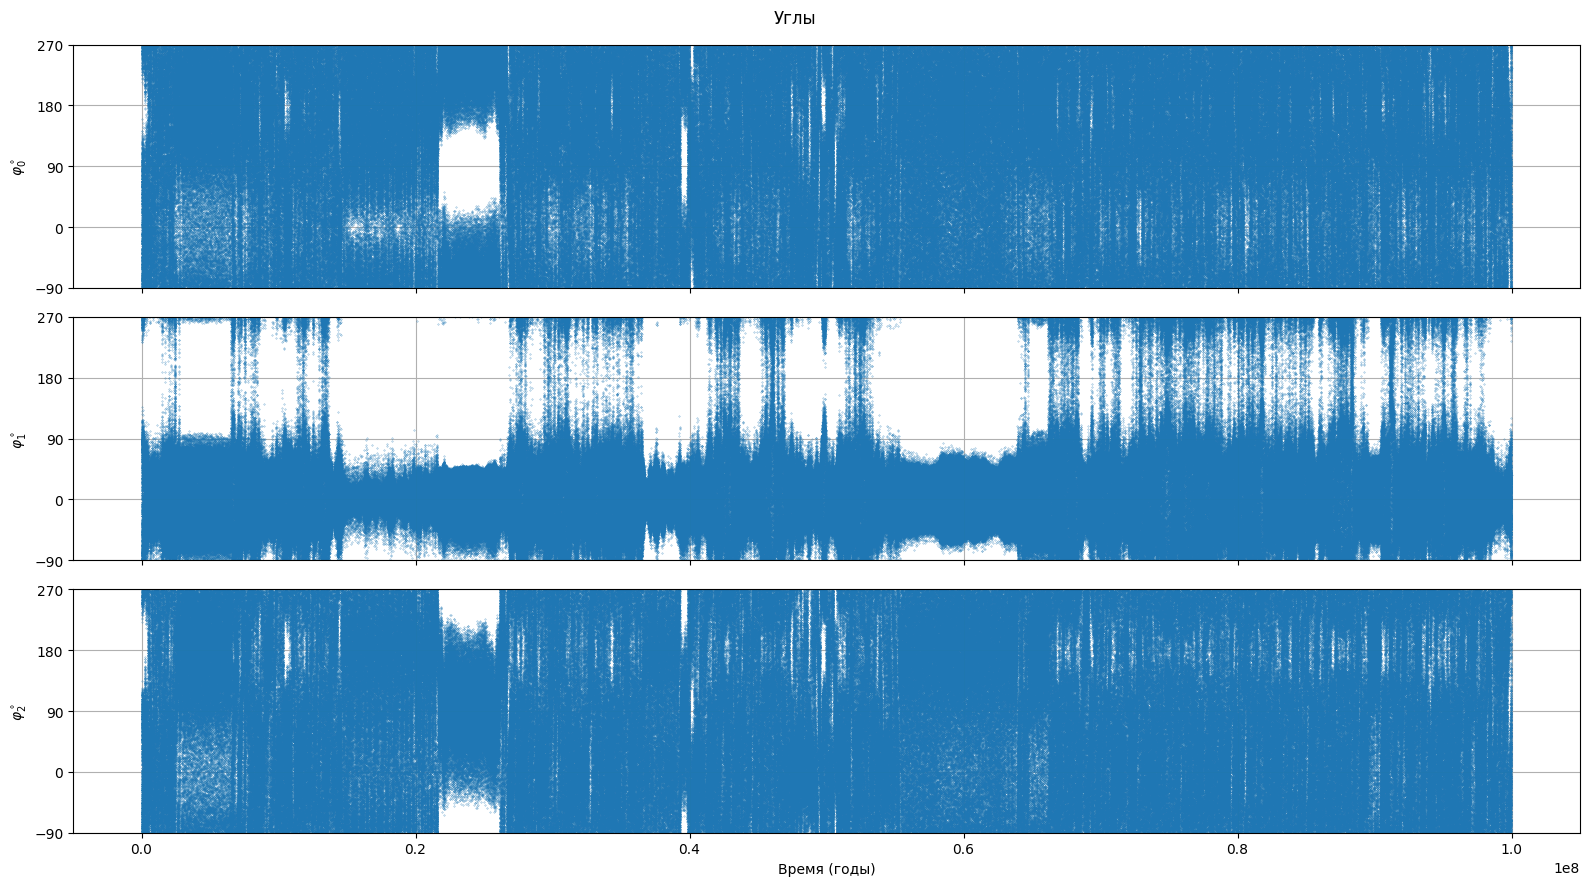

In [6]:
plot_angles(data['time_years'], data['angles_deg'], title='Углы',
            fig_width=16.,
            row_height=3.,)

In [7]:
windows = sliding_windows_multiplet(
    data_dict=data,
    window_length=4000,
    overlap_ratio=0.
)

In [18]:
model = load_model('1', models_dir=str(PROJECT_ROOT)+'/models/')

In [19]:
probs = predict_multiplet(windows['angle_windows'], model)

In [20]:
classes = [predict_classes_from_proba(p) for p in probs]

In [21]:
classes

[array([1, 1, 1, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 2, 1, 2, 2,
        1, 1, 1, 2, 2, 1, 2, 2, 1, 1, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 2, 2, 2, 2, 1, 1, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2,
        1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 1,
        1, 1, 1, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 2, 2, 2, 2,
        2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 2, 2, 2, 2, 2, 2, 1, 1, 1, 2, 2,
        2, 2, 2, 1, 1, 2, 2, 2, 2, 2, 2, 0, 2, 1, 0, 0, 2, 2, 2, 2, 2, 2,
        2, 2, 2, 2, 2, 2, 0, 1, 2, 2, 1, 2, 1, 2, 2, 2, 1, 2, 2, 2, 0, 0,
        0, 2, 2, 1, 1, 1, 2, 2, 0, 2, 2, 2, 1, 1, 2, 2, 2, 2, 2, 2, 1, 2,
        1, 1, 2, 1, 1, 1, 1, 1]),
 array([1, 1, 1, 1, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2,
        1, 1, 1, 1, 2, 1, 2, 2, 1, 1, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
    

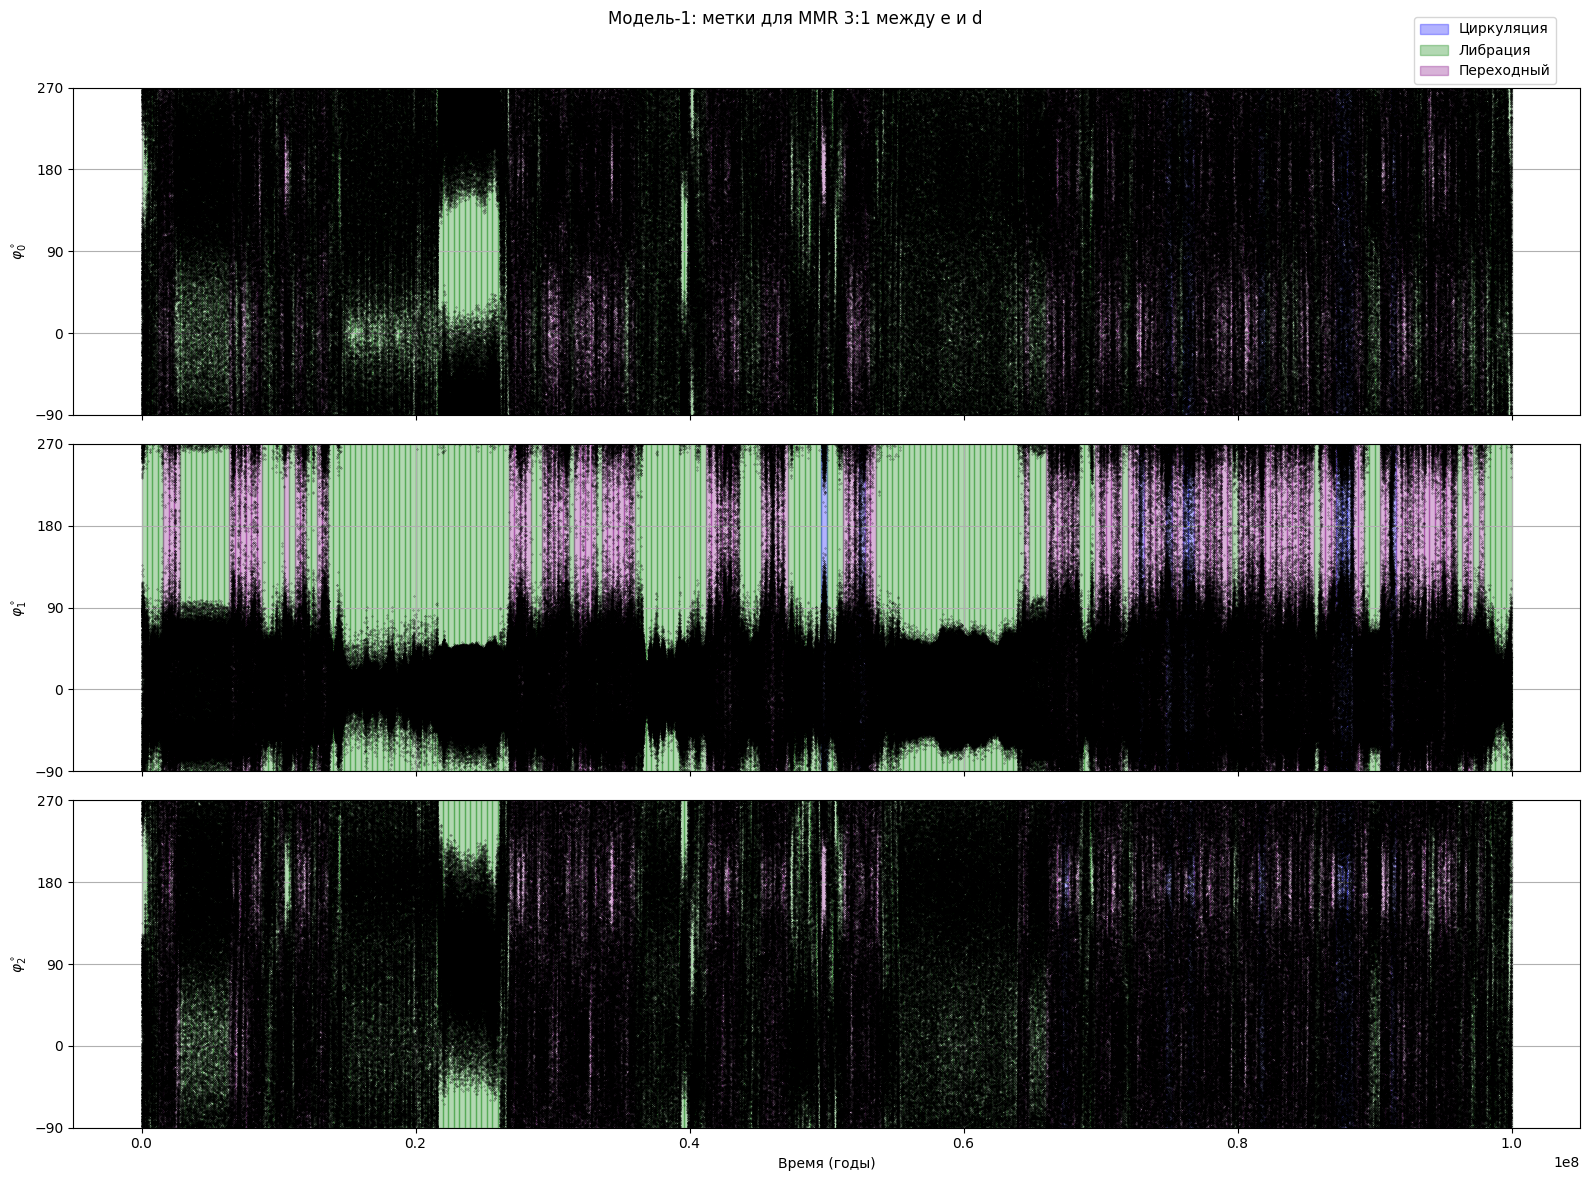

In [22]:
plot_multiplet_predictions(
    time_years=data['time_years'],
    angles_deg_list=data['angles_deg'],
    window_bounds=windows['window_bounds'],
    class_labels_list=classes,
    title='Модель-1: метки для MMR 3:1 между e и d',
    fig_width=16.,
    row_height=4.,
    # save_path=str(PROJECT_ROOT)+'/notebook/predict_TOI1136_model1.png'

)

In [13]:
model2 = load_model('2', models_dir=str(PROJECT_ROOT)+'/models/')

In [14]:
probs2 = predict_multiplet(windows['angle_windows'], model2)

In [15]:
classes2 = [predict_classes_from_proba(p) for p in probs2]

In [16]:
classes2

[array([1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
        2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 2, 2, 2, 2, 2, 2, 2,
        2, 1, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
        2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2,
        2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 1, 2, 2, 1, 2, 2, 2, 2, 2,
        2, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
        2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2,
        2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
        2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2,
        2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
        2, 2, 2, 2, 1, 2, 2, 2]),
 array([1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1,
        1, 1, 1, 1, 1, 2, 2, 2, 1, 1, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
    

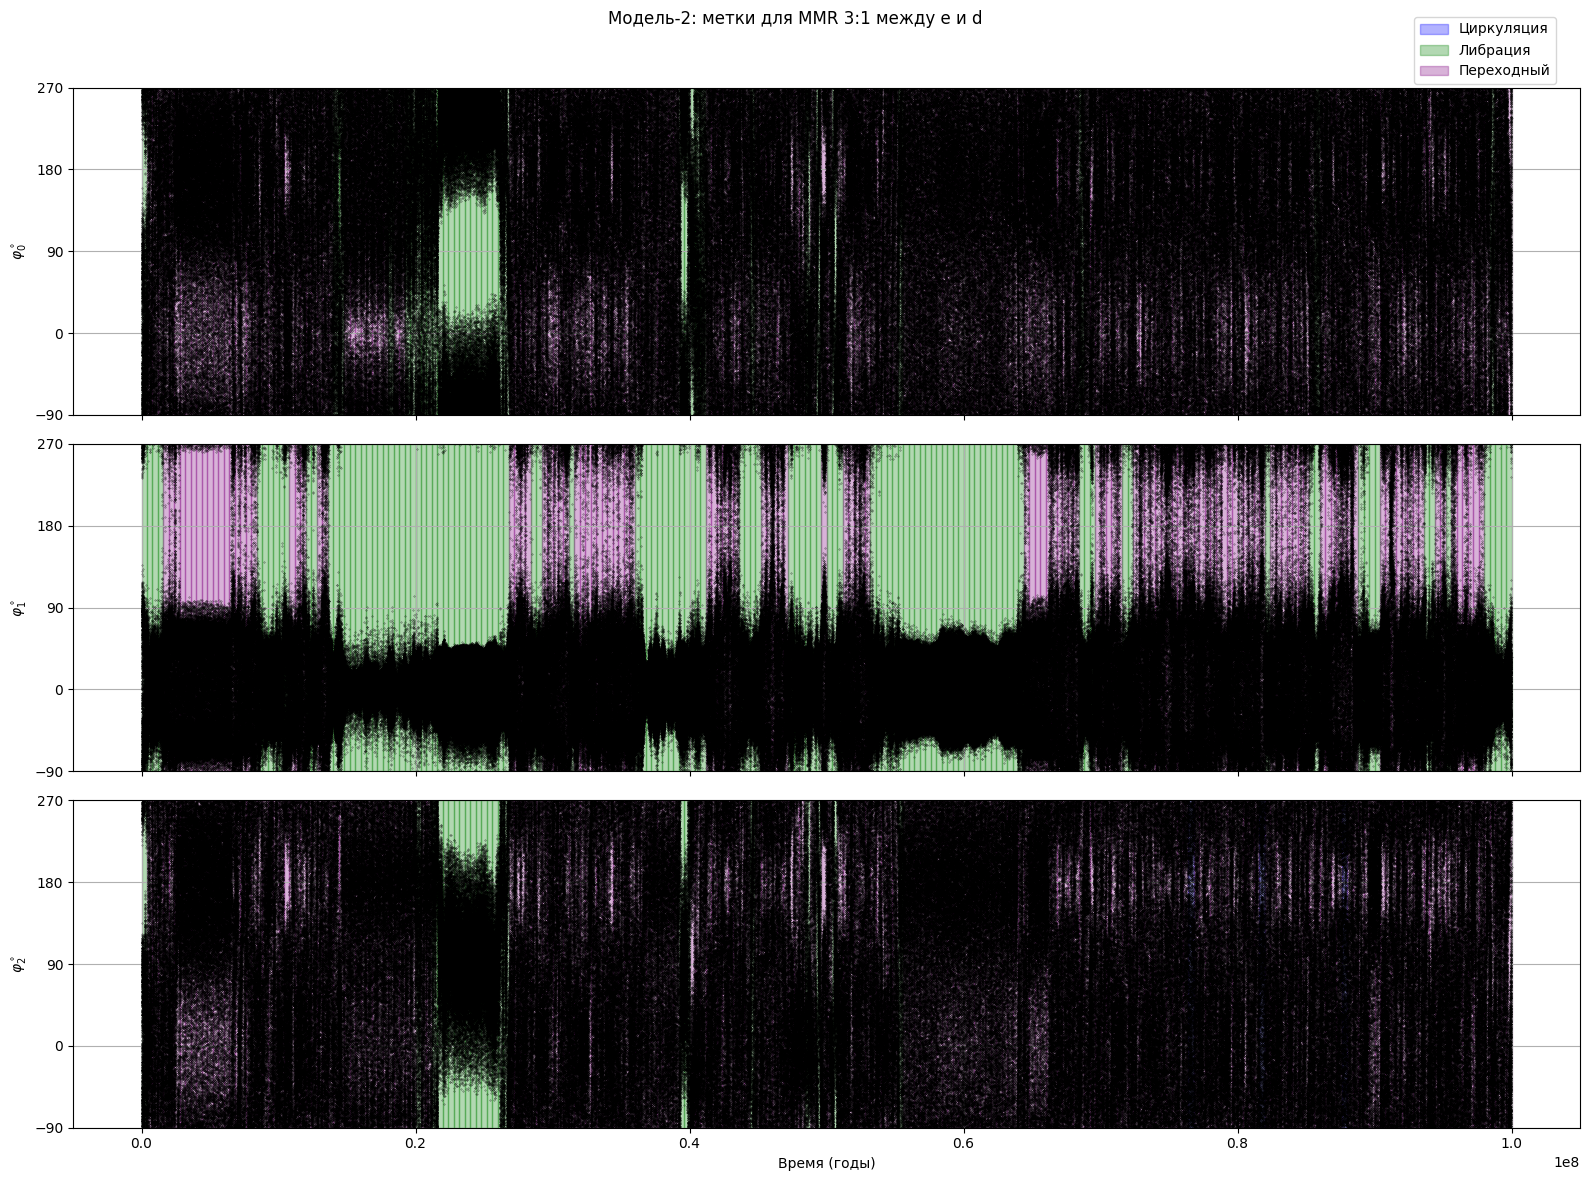

In [17]:
plot_multiplet_predictions(
    time_years=data['time_years'],
    angles_deg_list=data['angles_deg'],
    window_bounds=windows['window_bounds'],
    class_labels_list=classes2,
    title='Модель-2: метки для MMR 3:1 между e и d',
    fig_width=16.,
    row_height=4.,
    # save_path=str(PROJECT_ROOT)+'/notebook/predict_TOI1136_model1.png'

)

Модель некорректно классифицирует окна, веротяные проблемы:
1. Шаг между данными вырос в 40 раз (наиболее вероятный вариант)
2. Неправильная передача данных

In [ ]:
#Перекрытие в 1\2 окна

In [4]:
windows = sliding_windows_multiplet(
    data_dict=data,
    window_length=4000,
    overlap_ratio=0.5,
)

In [5]:
model = load_model('1', models_dir=str(PROJECT_ROOT)+'/models/')

W0000 00:00:1780776396.622282   69186 gpu_device.cc:2342] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [6]:
probs = predict_multiplet(windows['angle_windows'], model)

In [10]:
probs

[array([[4.3628080e-07, 9.7444910e-01, 2.5550447e-02],
        [5.4845596e-06, 9.5934123e-01, 4.0653344e-02],
        [5.0819563e-05, 9.4784403e-01, 5.2105203e-02],
        ...,
        [5.6677801e-03, 9.7384983e-01, 2.0482453e-02],
        [7.2480028e-04, 9.9069923e-01, 8.5760271e-03],
        [7.1938966e-06, 9.9595696e-01, 4.0357611e-03]],
       shape=(499, 3), dtype=float32),
 array([[2.5860156e-06, 9.8780924e-01, 1.2188083e-02],
        [4.8008395e-05, 9.9978733e-01, 1.6476224e-04],
        [8.5356412e-05, 9.9986482e-01, 4.9791186e-05],
        ...,
        [1.1664507e-05, 9.9997258e-01, 1.5739091e-05],
        [3.6212007e-06, 9.9999022e-01, 6.2256672e-06],
        [9.7512639e-06, 9.9973100e-01, 2.5920218e-04]],
       shape=(499, 3), dtype=float32),
 array([[3.9683133e-07, 9.7422099e-01, 2.5778590e-02],
        [2.6142136e-06, 9.0655792e-01, 9.3439527e-02],
        [1.5584748e-05, 8.6774671e-01, 1.3223770e-01],
        ...,
        [4.6427604e-03, 8.4371293e-01, 1.5164427e-01],
 

In [7]:
classes = [predict_classes_from_proba(p) for p in probs]

In [8]:
classes

[array([1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 1, 2, 2, 2, 1, 2, 2, 2, 2, 1,
        1, 1, 1, 1, 1, 1, 2, 2, 2, 1, 1, 2, 2, 2, 2, 2, 1, 1, 1, 1, 2, 2,
        2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2,
        2, 2, 1, 2, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
        1, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 0, 2, 2, 2, 2, 1, 1,
        1, 1, 1, 1, 1, 2, 2, 2, 2, 0, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 2, 2, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2,
        2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 

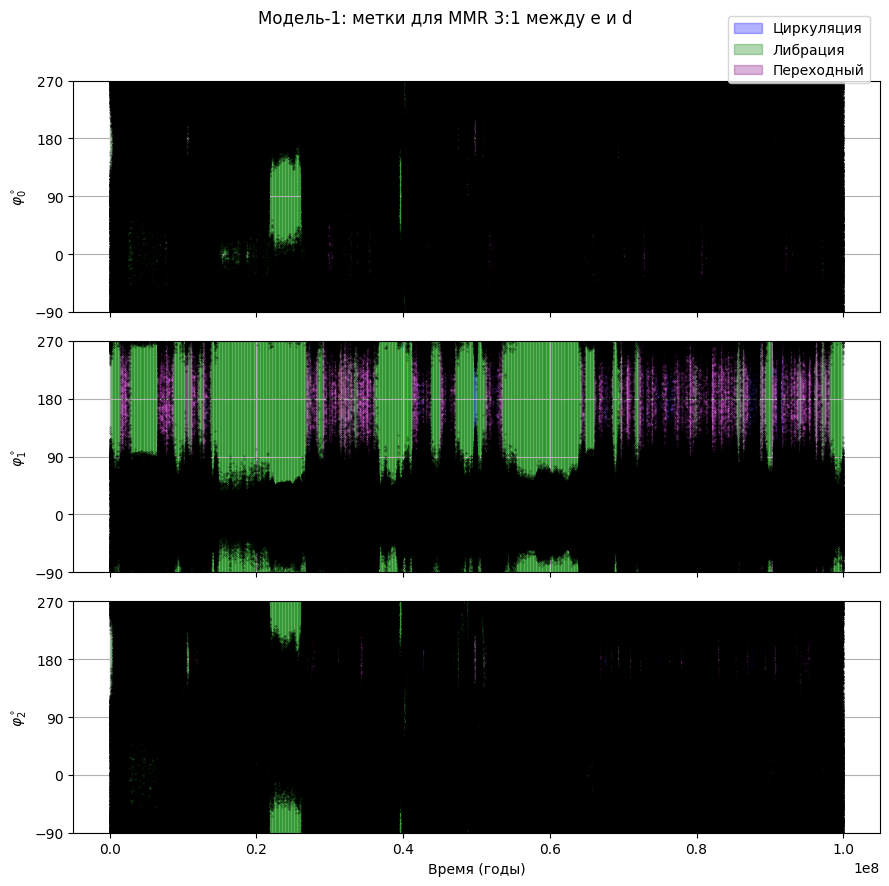

In [9]:
plot_multiplet_predictions(
    time_years=data['time_years'],
    angles_deg_list=data['angles_deg'],
    window_bounds=windows['window_bounds'],
    class_labels_list=classes,
    title='Модель-1: метки для MMR 3:1 между e и d',
    fig_width=9.,
    row_height=3.,
    # save_path=str(PROJECT_ROOT)+'/notebook/predict_TOI1136_model1.png'

)

In [14]:
import numpy as np
data_path_seq=str(PROJECT_ROOT)+'/time_series/angles_inside_2_1/8_mmr/kepler-51_elem_1_secular.npz'
data_s = np.load(data_path_seq)
print(data_s.files) 

['time', 'delta_longitude_raw']


In [25]:
#Вековой

data_path_seq=str(PROJECT_ROOT)+'/time_series/angles_inside_2_1/8_mmr/kepler-51_elem_1_secular.npz'
data_seq = load_angles(data_path_seq, angle_columns=['delta_longitude_raw'],
                   time_column='time', angle_unit='deg', convert_to_xy=True)

In [26]:
windows_seq = sliding_windows_multiplet(
    data_dict=data_seq,
    window_length=4000,
    overlap_ratio=0.
)

In [33]:
model = load_model('1', models_dir=str(PROJECT_ROOT)+'/models/')

In [34]:
probs = predict_multiplet(windows_seq['angle_windows'], model)

In [35]:
classes = [predict_classes_from_proba(p) for p in probs]

In [36]:
classes

[array([2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 0, 2, 2,
        2, 2, 2, 2, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
        2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
        2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 0, 0, 2, 2, 0, 2, 2, 0, 0,
        2, 2, 2, 2, 1, 2, 1, 1, 1, 1, 1, 2, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2,
        2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 2, 1, 2, 2, 1, 2, 1, 2, 2, 0, 2, 2,
        2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
        2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
        2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
        2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 0, 2, 2, 2,
        2, 2, 1, 2, 2, 2, 2, 1, 2, 2, 2, 2, 1, 2, 2, 1, 2, 2, 2, 2, 2, 2,
        2, 2, 2, 2, 2, 2, 2, 2])]

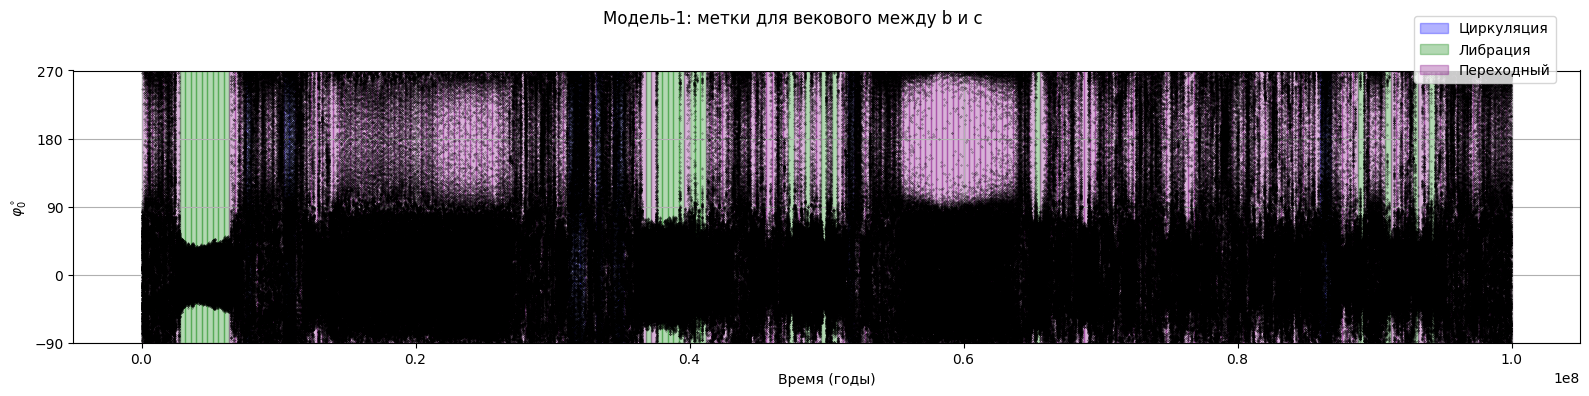

In [37]:
plot_multiplet_predictions(
    time_years=data_seq['time_years'],
    angles_deg_list=data_seq['angles_deg'],
    window_bounds=windows_seq['window_bounds'],
    class_labels_list=classes,
    title='Модель-1: метки для векового между b и c ',
    fig_width=16.,
    row_height=4,
    # save_path=str(PROJECT_ROOT)+'/notebook/predict_TOI1136_model1.png'

)

Увеличение шага в 40 раз, не так значительно сказывается на вековых углав (долгопериодические переменные), в отличии от резонансов средних движений, которые уже содержат быстрые (срдние движения; средние аномалии).
Характерные признаки не замылись для вековых углов при переходе от 2.5 лет к 100 годам между точками

In [27]:
model2 = load_model('2', models_dir=str(PROJECT_ROOT)+'/models/')

In [28]:
probs2 = predict_multiplet(windows_seq['angle_windows'], model2)

In [29]:
classes2 = [predict_classes_from_proba(p) for p in probs2]

In [30]:
classes2

[array([1, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 0, 2, 2,
        2, 2, 2, 2, 0, 0, 2, 2, 1, 1, 2, 2, 1, 2, 2, 2, 1, 1, 1, 1, 1, 1,
        2, 1, 2, 1, 2, 2, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 0, 0, 2, 2, 0, 2, 2, 0, 0,
        2, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2,
        2, 1, 2, 2, 1, 1, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 0, 0, 2,
        2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 2, 2, 2, 2, 2, 2, 1, 2, 2, 2, 1, 2, 2, 2, 1, 1, 1, 2, 2,
        2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0,
        2, 2, 2, 2, 2, 2, 2, 1, 2, 1, 2, 2, 1, 2, 2, 2, 1, 2, 0, 2, 2, 1,
        1, 1, 1, 2, 2, 2, 2, 1, 1, 1, 1, 2, 2, 2, 1, 1, 2, 2, 2, 2, 2, 2,
        2, 2, 2, 2, 2, 2, 2, 2])]

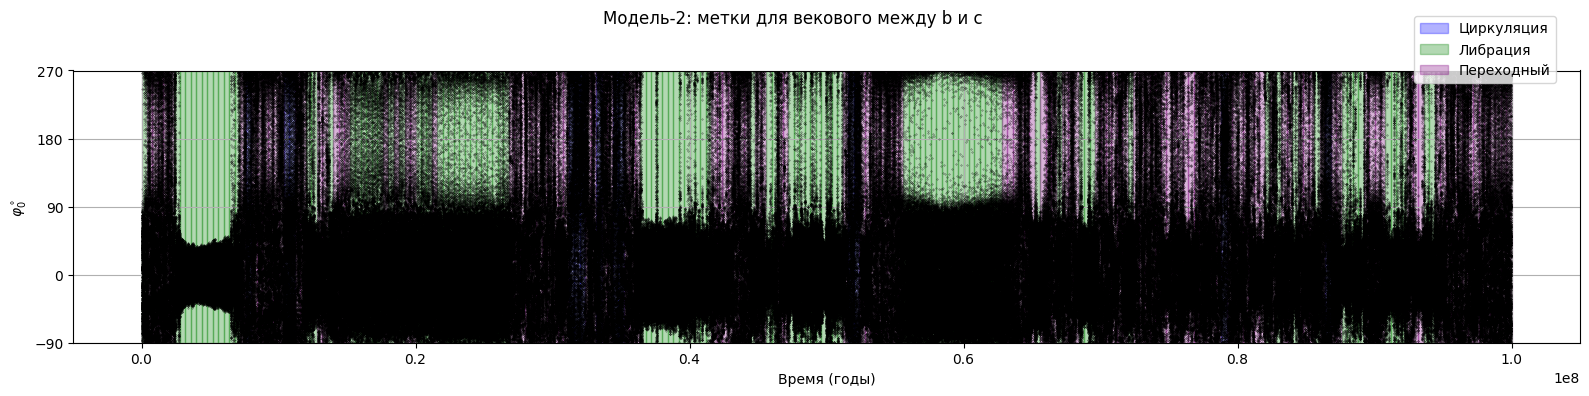

In [32]:
plot_multiplet_predictions(
    time_years=data_seq['time_years'],
    angles_deg_list=data_seq['angles_deg'],
    window_bounds=windows_seq['window_bounds'],
    class_labels_list=classes2,
    title='Модель-2: метки для векового между b и c ',
    fig_width=16.,
    row_height=4,
    # save_path=str(PROJECT_ROOT)+'/notebook/predict_TOI1136_model1.png'

)